# **Setup**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/My Drive/lisboa_ciencia_de_dados/2_sem/proteins_AF')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
! sudo apt-get install -qq graphviz graphviz-dev
! pip install -qq rdkit shap pygraphviz igraph
! pip install -qq catboost lightgbm xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.7 MB/s eta 0:00:00


# **Imports**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
warnings.filterwarnings("ignore", category=RuntimeWarning)

from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, AllChem, rdEHTTools, rdmolops, Draw
from scipy.linalg import eigvals
import networkx as nx
import igraph as ig

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import shap
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

from dataclasses import dataclass
from typing import List, Union, Optional, Tuple, Any


# **FingerPrints Extraction Tool**

# Physicochemical Feature Extractor

This section handles the extraction of molecular descriptors from both 2D graphs and 3D conformations. We transition from a simple string representation (SMILES) to mathematical objects that describe the thermodynamics and quantum mechanics of ligand-target binding.

### 1. Short-Range Topology (Morgan Fingerprints)
Decomposition of the molecular graph into a binary vector. This describes the presence of specific functional groups (pharmacophores) within a radius of 2 bonds. These act as steric and electrostatic "anchors" during binding.

### 2. Macroscopic Electrostatics and Topology (2D Physics)
* **Charge Span ($\Delta Q$)**: A surrogate for the dipole moment. Evaluated using the Gasteiger method (iterative partial equalization of orbital electronegativities). Describes long-range Coulomb attractive forces.
* **Laplacian Spectrum**: The Kirchhoff matrix of the molecular graph, defined as $L = D - A$.
  * **Spectral Radius ($\lambda_{max}$)**: Describes the degree of branching in the molecular skeleton.
  * **Algebraic Connectivity ($\lambda_2$, Fiedler value)**: Describes the compactness of the graph. This strictly correlates with the conformational entropy penalty ($-T\Delta S$) upon ligand binding.

### 3. Quantum Mechanics & Coulomb Matrix (3D Physics)
* **Extended Hückel Theory (EHT)**: A semi-empirical method for calculating molecular orbitals. We extract the Fermi energy ($E_F$) and the total electronic energy of the system.
* **Coulomb Matrix ($C_{ij}$)**: Describes the electrostatic repulsion of nuclei in 3D space:
$$C_{ij} = \begin{cases} \frac{1}{2} Z_i^{2.4} & \text{if } i = j \\ \frac{Z_i Z_j}{|R_i - R_j|} & \text{if } i \neq j \end{cases}$$
To ensure the features are invariant to atom indexing, rotation, and translation, we extract the eigenvalues of matrix $C$.

### 4. Advanced Topology & Shape Geometry (2D & 3D)
* **Wiener Index ($W$)**: A topological descriptor defined as half the sum of the shortest path distances ($d_{ij}$) between all pairs of vertices in the molecular graph:
  $$W = \frac{1}{2} \sum_{i} \sum_{j} d_{ij}$$
  It correlates strongly with the spatial extent and flexibility of the molecule, serving as a proxy for the dispersive Van der Waals interactions and macroscopic entropy.
* **SASA (Solvent Accessible Surface Area)**: The geometric surface area of the molecule that is accessible to a solvent (typically water). Crucial for estimating the free energy of solvation ($\Delta G_{solv}$) and macroscopic hydrophobic effects during ligand-target binding.
* **Normalized Principal Moments of Inertia (NPR)**: Ratios of the principal moments of inertia ($I_1 \le I_2 \le I_3$).
  * $NPR_1 = I_1 / I_3$
  * $NPR_2 = I_2 / I_3$
  These metrics project the molecule into a 2D shape-space (rod, disk, or sphere), decoupling the pure geometric form of the molecule from its macroscopic mass.

In [ ]:
class FeatureExtractor:
    """
    Utility class for extracting physicochemical and topological descriptors
    from RDKit molecule objects. No initialization required (all methods are static/class methods).
    """
    mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

    @classmethod
    def get_morgan_fp(cls, mol_obj: Chem.Mol) -> Union[np.ndarray, float]:
        """
        Generates a binary Morgan fingerprint (ECFP4-like).

        Args:
            mol_obj (Chem.Mol): RDKit molecule object.
        Returns:
            np.ndarray: A binary vector of length 1024. Returns np.nan on failure.
        """
        if mol_obj is None:
            return np.nan
        return cls.mfpgen.GetFingerprintAsNumPy(mol_obj)

    @staticmethod
    def get_physics_2d(mol_obj: Chem.Mol) -> List[float]:
        """
        Calculates 2D physical descriptors: Gasteiger charge span and
        the eigenvalues of the molecular graph's Laplacian matrix.

        Args:
            mol_obj (Chem.Mol): RDKit molecule object.
        Returns:
            List[float]: [Delta_Q, Lambda_Max, Lambda_Fiedler].
                         Returns zeros/np.nan on failure.
        """
        if mol_obj is None:
            return [np.nan, np.nan, np.nan]

        # Electrostatics
        try:
            AllChem.ComputeGasteigerCharges(mol_obj)
            charges = [float(atom.GetProp('_GasteigerCharge')) for atom in mol_obj.GetAtoms()]
            charges = [c for c in charges if not np.isnan(c) and not np.isinf(c)]
            delta_q = max(charges) - min(charges) if charges else 0
        except Exception:
            delta_q = 0

        # Topology (Graph Spectrum)
        try:
            A = Chem.GetAdjacencyMatrix(mol_obj)
            G = nx.from_numpy_array(A)
            L = nx.laplacian_matrix(G).todense()
            eigenvalues = np.sort(np.real(eigvals(L)))
            lambda_max = eigenvalues[-1] if len(eigenvalues) > 0 else 0
            lambda_fiedler = eigenvalues[1] if len(eigenvalues) > 1 else 0
        except Exception:
            lambda_max, lambda_fiedler = 0, 0

        return [delta_q, lambda_max, lambda_fiedler]

    @staticmethod
    def get_3d_physics(mol_obj: Chem.Mol) -> List[float]:
        """
        Generates a 3D conformation (ETKDGv3) and calculates quantum-mechanical
        parameters (EHT) alongside the Coulomb matrix spectrum. Includes a hardware
        interlock to prevent Coulomb singularities.

        Args:
            mol_obj (Chem.Mol): RDKit molecule object.
        Returns:
            List[float]: [Fermi_Energy, Total_EHT_Energy, Coulomb_Max, Coulomb_Trace].
        """
        if mol_obj is None:
            return [np.nan] * 4

        mol = Chem.AddHs(mol_obj)
        params = AllChem.ETKDGv3()
        params.randomSeed = 42
        params.maxIterations = 200

        if AllChem.EmbedMolecule(mol, params) == -1:
            return [np.nan] * 4

        # Interlock to prevent atom collision singularity (< 0.4 A)
        try:
            dist_matrix = rdmolops.Get3DDistanceMatrix(mol)
            np.fill_diagonal(dist_matrix, 100)
            if np.min(dist_matrix) < 0.4:
                return [np.nan] * 4
        except Exception:
            return [np.nan] * 4

        # Quantum Mechanics (EHT)
        try:
            passed, eht_res = rdEHTTools.RunMol(mol)
            fermi_energy = eht_res.GetFermiEnergy() if passed else np.nan
            total_energy = eht_res.GetTotalEnergy() if passed else np.nan
        except Exception:
            fermi_energy, total_energy = np.nan, np.nan

        # Coulomb Matrix
        try:
            num_atoms = mol.GetNumAtoms()
            C = np.zeros((num_atoms, num_atoms))
            for i in range(num_atoms):
                Zi = mol.GetAtomWithIdx(i).GetAtomicNum()
                for j in range(i, num_atoms):
                    Zj = mol.GetAtomWithIdx(j).GetAtomicNum()
                    if i == j:
                        C[i][i] = 0.5 * (Zi ** 2.4)
                    else:
                        coulomb_val = (Zi * Zj) / dist_matrix[i][j]
                        C[i][j] = coulomb_val
                        C[j][i] = coulomb_val # Enforce symmetry

            eigenvalues = np.sort(np.real(eigvals(C)))
            coulomb_max = eigenvalues[-1] if len(eigenvalues) > 0 else 0
            coulomb_trace = np.trace(C)
        except Exception:
            coulomb_max, coulomb_trace = np.nan, np.nan

        return [fermi_energy, total_energy, coulomb_max, coulomb_trace]

    @staticmethod
    def get_advanced_features(mol_obj):
        """
        Calculates advanced 2D and 3D descriptors: Wiener Index, SASA, and Normalized PMI.
        Expects a basic RDKit Mol object.
        Note: 3D features require embedding, which is computationally expensive.
        """
        from rdkit.Chem import rdMolDescriptors
        from rdkit.Chem import rdFreeSASA

        if mol_obj is None:
            return [np.nan] * 4

        # 1. Wiener Index (Topological - 2D)
        # It's simply half the sum of the shortest path distance matrix
        try:
            dist_matrix_2d = Chem.GetDistanceMatrix(mol_obj)
            wiener_index = 0.5 * np.sum(dist_matrix_2d)
        except:
            wiener_index = np.nan

        # Prepare 3D conformation for SASA and PMI
        mol_3d = Chem.AddHs(mol_obj)
        params = AllChem.ETKDGv3()
        params.randomSeed = 42

        if AllChem.EmbedMolecule(mol_3d, params) == -1:
            return [wiener_index, np.nan, np.nan, np.nan]

        # 2. SASA (Solvent Accessible Surface Area)
        try:
            # Classify atoms to assign Van der Waals radii
            radii = rdFreeSASA.classifyAtoms(mol_3d)
            sasa = rdFreeSASA.CalcSASA(mol_3d, radii)
        except:
            sasa = np.nan

        # 3. Normalized Principal Moments of Inertia (NPR1, NPR2)
        # PMI1 <= PMI2 <= PMI3.
        # NPR1 = PMI1/PMI3, NPR2 = PMI2/PMI3
        # These map the molecule to a triangle plot (Rod vs Disk vs Sphere)
        try:
            pmi1 = rdMolDescriptors.CalcPMI1(mol_3d)
            pmi3 = rdMolDescriptors.CalcPMI3(mol_3d)

            if pmi3 > 1e-4: # Prevent division by zero
                npr1 = pmi1 / pmi3
                npr2 = rdMolDescriptors.CalcPMI2(mol_3d) / pmi3
            else:
                npr1, npr2 = np.nan, np.nan
        except:
            npr1, npr2 = np.nan, np.nan

        return [wiener_index, sasa, npr1, npr2]

# **Data Analytics**

### Analytical Tools

This module provides tools to inspect the physical meaning behind the machine learning model's predictions and the underlying dataset properties.

* **Feature Importance**: Ranks the physical and topological descriptors by their contribution to the binding energy prediction ($\Delta G$). Colors are used to visually separate thermodynamic macros-features, quantum/electrostatic fields, and local topology.
* Utilizes **SHapley Additive exPlanations (SHAP)**, a game-theoretic approach to explain the output of the machine learning model. By computing Shapley values, we can decompose the predicted binding energy ($\Delta G$) for each molecule into the sum of contributions from individual physicochemical features. This breaks the "black box" and reveals the exact physical vectors (e.g., electrostatic repulsion or specific structural anchors) driving the prediction.
* **Fragment Visualization (Morgan Bits)**: Allows decoding a specific abstract Morgan fingerprint bit back into its 2D chemical structure. This is crucial for identifying structural "anchors" (pharmacophores) that strictly define the binding affinity.
* **Exploratory Data Analysis (EDA)**: Visualizes the macroscopic thermodynamic state of the dataset, including the lipophilicity phase portrait and the correlation between steric bulk (mass) and binding energy.
* **Correlation Analysis**: Generates a Pearson correlation matrix heatmap for continuous physical and quantum features.  This tool is essential for detecting multicollinearity and ensuring the linear independence of our physicochemical basis. By identifying redundant thermodynamic or electrostatic descriptors, we prevent feature importance distortion and ensure the model relies on a truly orthogonal set of physical signals.

In [ ]:
class DataAnalytics:
    @staticmethod
    def plot_feature_importance(model, feature_names: list, top_n: int = 15):
        """
        Plots the top N most important features from the trained model.
        Colors indicate the physical nature of the feature (e.g., thermodynamics, electrostatics).

        Args:
            model: Trained machine learning model (must have feature_importances_).
            feature_names (list): List of feature names corresponding to the model's inputs.
            top_n (int): Number of top features to display. Default is 15.
        """
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1][:top_n]

        top_names = [feature_names[i] for i in indices]
        top_importances = importances[indices]

        plt.figure(figsize=(10, 5))
        plt.title(f"Top-{top_n} Features Determining Binding Energy ($\Delta G$)", fontsize=14)
        bars = plt.bar(range(top_n), top_importances, color='steelblue', align="center")

        # Color-code the physical features for better interpretability
        for i, name in enumerate(top_names):
            if name in ['Molecular Weight', 'AlogP']:
                bars[i].set_color('darkred')
            elif name in ['Delta_Q', 'Lambda_Max', 'Lambda_Fiedler']:
                bars[i].set_color('goldenrod')
            elif name in ['Fermi_Energy', 'Total_EHT_Energy', 'Coulomb_Max', 'Coulomb_Trace']:
                bars[i].set_color('purple')

        plt.xticks(range(top_n), top_names, rotation=45, ha='right')
        plt.ylabel("Importance (Error Reduction)")
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_shap_analysis(model, X_test, feature_names, sample_size=200):
        """
        Performs SHAP analysis for feature importance. Automatically selects
        the appropriate Explainer type based on the model architecture.
        """
        print("Calculating SHAP values (analyzing physical contributions)...")
        X_sample = X_test[:sample_size]

        try:
            # Attempt fast tree-based algorithm (RF, CatBoost, XGBoost)
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_sample, check_additivity=False)
        except Exception:
            # Fallback for non-tree models (SVR, Neural Networks)
            print("TreeExplainer failed, falling back to universal Explainer...")
            explainer = shap.Explainer(model.predict, X_sample)
            shap_values = explainer(X_sample).values

        plt.figure(figsize=(10, 6))
        plt.title("SHAP Summary Plot:")
        shap.summary_plot(shap_values, X_sample, feature_names=feature_names, max_display=15)


    @staticmethod
    def draw_morgan_bit(df: pd.DataFrame, target_bit: int, radius: int = 2, nBits: int = 1024):
        """
        Searches the dataset for a molecule containing the specified Morgan fingerprint bit
        and renders the 2D chemical structure of that specific fragment.

        Args:
            df (pd.DataFrame): DataFrame containing 'Mol_obj' (RDKit molecule objects).
            target_bit (int): The integer ID of the bit to visualize.
            radius (int): Morgan fingerprint radius used during generation.
            nBits (int): Morgan fingerprint bit vector length.
        """
        print(f"Scanning the dataset for the presence of bit {target_bit}...")
        example_mol = None
        bit_info = {}

        for mol in df['Mol_obj']:
            info = {}
            AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=nBits, bitInfo=info)
            if target_bit in info:
                example_mol = mol
                bit_info = info
                break

        if example_mol:
            print("Fragment found! Displaying the 2D structure...")
            img = Draw.DrawMorganBit(example_mol, target_bit, bit_info)
            display(img)
        else:
            print(f"Warning: Bit {target_bit} was not found in any molecule of the current dataset.")

    @staticmethod
    def plot_eda(df: pd.DataFrame):
        """
        Performs Exploratory Data Analysis (EDA) by plotting the dataset's
        thermodynamic phase portrait (AlogP distribution) and steric bounds
        (Molecular Weight vs. pChEMBL Value).

        Args:
            df (pd.DataFrame): DataFrame containing 'AlogP', 'Molecular Weight', and 'pChEMBL Value'.
        """
        print("Running Exploratory Data Analysis (EDA)...")
        plt.figure(figsize=(12, 5))

        # Plot 1: Lipophilicity Spectrum
        plt.subplot(1, 2, 1)
        plt.hist(df['AlogP'].dropna(), bins=50, color='teal', edgecolor='black')
        plt.title('Phase Portrait: AlogP Distribution')
        plt.xlabel('AlogP (Calculated Lipophilicity)')
        plt.ylabel('Molecule Count')
        plt.xlim([-5, 10])

        # Plot 2: Energy vs. Mass
        plt.subplot(1, 2, 2)
        plt.scatter(df['Molecular Weight'], df['pChEMBL Value'], alpha=0.3, s=10, color='darkred')
        plt.title('Binding Energy vs. Molecular Weight')
        plt.xlabel('Molecular Weight (Da)')
        plt.ylabel('pChEMBL Value ($\sim \Delta G$)')

        plt.tight_layout()
        plt.show()

    @staticmethod
    def check_correlations(df, feature_cols, plot=True):
        """
        Calculates the Pearson correlation matrix for a given set of continuous features.
        Ignores binary fingerprints (like Morgan) as Pearson correlation is not meaningful for them.
        """
        print("Scanning features for multicollinearity...")

        # Keep only the columns that have already been calculated and exist in the dataframe
        available_cols = [col for col in feature_cols if col in df.columns]

        if not available_cols:
            print("Warning: Features have not been calculated yet!")
            return None

        # Calculate the correlation matrix
        corr_matrix = df[available_cols].corr(method='pearson')

        if plot:
            plt.figure(figsize=(10, 8))

            # Create a mask for the upper triangle to make the heatmap cleaner
            mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

            # Plot the heatmap
            sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
                        cmap='coolwarm', vmin=-1, vmax=1,
                        square=True, linewidths=.5, cbar_kws={"shrink": .7})

            plt.title("Correlation Matrix of Physicochemical Features", fontsize=14)
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            plt.show()

        return corr_matrix

<>:20: SyntaxWarning: invalid escape sequence '\D'
<>:119: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\D'
<>:119: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_47835/1590224847.py:20: SyntaxWarning: invalid escape sequence '\D'
  plt.title(f"Top-{top_n} Features Determining Binding Energy ($\Delta G$)", fontsize=14)
/tmp/ipykernel_47835/1590224847.py:119: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('pChEMBL Value ($\sim \Delta G$)')


# **Extract & Transform & Load Pipeline**

This section handles the ingestion and purification of the raw ChEMBL dataset. In physical terms, this is our "signal filtering" stage.

### Data Cleaning Protocol:
1. **Signal Isolation**: We filter strictly for exact inhibition constant measurements (`Standard Type == 'Ki'` and `Standard Relation == '='`). Inequality measurements (>, <) are discarded as they represent censored data (noise) that conflates exact thermodynamic states.
2. **Sanitization**: Null values in critical target variables ($pChEMBL$) or structural representations (SMILES) are removed. Variables are strictly cast to numeric types.
3. **Graph Instantiation**: SMILES strings are parsed into functional 2D mathematical graphs (`RDKit Mol` objects). This is the crucial step where textual representations are converted into the topological objects required for all subsequent quantum and physical feature extraction.

In [ ]:
class DataLoader:
    """
    Handles data ingestion, filtering, and initial preprocessing of chemical datasets.
    Responsible for isolating high-confidence signals and converting raw SMILES strings
    into RDKit molecular objects.
    """

    @staticmethod
    def load_and_clean(filepath: str = "molecules_chembl_ki/chembl224.csv", sample_size: Optional[int] = None) -> pd.DataFrame:
        """
        Loads the dataset, filters for exact Ki values, handles missing data,
        and instantiates RDKit molecule objects.

        Args:
            filepath (str): Path to the raw dataset CSV file.
            sample_size (int, optional): If provided, randomly samples the dataset
                                         to this specific size for rapid prototyping.

        Returns:
            pd.DataFrame: A purified DataFrame ready for physical feature extraction.
        """
        print("Initializing Data Loading and Cleaning protocol...")
        df = pd.read_csv(filepath, sep=';')

        # Isolate physically relevant macroscopic columns
        cols = ['Molecular Weight', 'AlogP', 'Smiles', 'Standard Type', 'Standard Relation', 'pChEMBL Value']
        # cols = ['Molecule ChEMBL ID', 'Molecular Weight', '#RO5 Violations', 'AlogP', 'Smiles', 'Standard Type', 'Standard Relation', 'Standard Value', 'Standard Units', 'pChEMBL Value']
        df = df[cols]

        # 1. Signal Isolation: Filter for exact Ki measurements
        df = df[(df['Standard Type'] == 'Ki') & (df['Standard Relation'] == "'='")]
        df = df.dropna(subset=['Smiles', 'pChEMBL Value'])

        # 2. Type Casting
        df['Molecular Weight'] = pd.to_numeric(df['Molecular Weight'], errors='coerce')
        df['AlogP'] = pd.to_numeric(df['AlogP'], errors='coerce')

        # 3. Graph Instantiation (SMILES to RDKit Mol)
        print("Parsing SMILES strings into RDKit molecular graphs...")
        df['Mol_obj'] = df['Smiles'].apply(Chem.MolFromSmiles)

        # Discard molecules that failed RDKit parsing
        df = df.dropna(subset=['Mol_obj'])

        # Optional sub-sampling for pipeline calibration
        if sample_size:
            print(f"Sub-sampling dataset to {sample_size} instances...")
            df = df.sample(n=sample_size, random_state=42).copy()

        print(f"ETL Complete! The purified dataset contains {len(df)} valid molecules.")
        return df

# **Settings**

### Experimental Settings (Control Panel)
A configuration interface (`ExperimentSettings`) that allows toggling different physical interactions on and off.
* Do we want to test if macroscopic thermodynamics alone can predict binding? Turn off Morgan fingerprints.
* Do we want to introduce quantum repulsion? Turn on 3D physics.

In [ ]:
@dataclass
class ExperimentSettings:
    """
    Configuration data class acting as the control panel for the ML experiment.
    Toggles determine which physicochemical spaces are included in the feature tensor X.
    """
    USE_MORGAN: bool = True       # Short-range topology (Pharmacophores)
    USE_MACRO: bool = True        # Thermodynamics (AlogP, Molecular Weight)
    USE_2D_PHYSICS: bool = True   # Graph Laplacians & Charge gradients
    USE_3D_PHYSICS: bool = False  # EHT Quantum features & Coulomb Matrix (Computationally expensive)
    USE_ADVANCED: bool = True     # Wiener Index, Solvent Accessible Surface Area, Principal Moments of Inertia
    TEST_SIZE: float = 0.2        # Hold-out test set fraction
    RANDOM_STATE: int = 42        # Seed for reproducibility


# **Machine Learning Orchestration**

### The Experiment Runner (Model Agnostic Pipeline)
This class handles the end-to-end machine learning lifecycle:
1. **Tensor Assembly**: Dynamically constructs the feature matrix $X$ by invoking the `FeatureExtractor` only for the enabled physical dimensions.
2. **Phase Space Splitting**: Separates the dataset into training and strictly isolated test sets to prevent data leakage and evaluate generalization.
3. **Model Fitting**: Optimizes the parameters of the provided estimator (Random Forest, Gradient Boosting, etc.) to map the physicochemical space to the free energy of binding ($\Delta G$).
4. **Physical Metrics Evaluation**:
   * $R^2$: The proportion of the variance in binding energy explained by our physical features.
   * $RMSE$ & $MAE$: Absolute error metrics denoting how many logarithmic units ($pKi$) the model deviates from the experimental ground truth.
5. **State Serialization**: Saves the trained model and feature mapping to disk for future inference or external validation.

In [ ]:
class ExperimentRunner:
    """
    Orchestrates the machine learning lifecycle: feature assembly, training,
    evaluation, and visualization. Designed to be model-agnostic.
    """

    def __init__(self, model: Any, settings: ExperimentSettings):
        """
        Args:
            model (Any): An instantiated scikit-learn compatible estimator (e.g., RandomForestRegressor).
            settings (ExperimentSettings): Configuration object for feature selection.
        """
        self.model = model
        self.settings = settings
        self.feature_names = []
        self.metrics = {}

    def _build_features(self, df: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray]:
        """
        Dynamically constructs the feature matrix X and target vector y based on the provided settings.
        Calculates features on-the-fly if they are not already present in the DataFrame.

        Args:
            df (pd.DataFrame): The purified dataset containing 'Mol_obj' and 'pChEMBL Value'.

        Returns:
            Tuple[np.ndarray, np.ndarray]: Feature matrix X and target vector y.
        """
        features_list = []
        self.feature_names = []

        print("Assembling the physicochemical feature tensor...")

        # 1. Morgan Fingerprints
        if self.settings.USE_MORGAN:
            if 'MorganFP' not in df.columns:
                df['MorganFP'] = df['Mol_obj'].apply(FeatureExtractor.get_morgan_fp)
            features_list.append(np.vstack(df['MorganFP'].values))
            self.feature_names.extend([f'Bit_{i}' for i in range(1024)])

        # 2. Macroscopic Thermodynamics
        if self.settings.USE_MACRO:
            # Impute highly rare missing values with the median to preserve tensor integrity
            macro_data = df[['Molecular Weight', 'AlogP']].fillna(df[['Molecular Weight', 'AlogP']].median())
            features_list.append(macro_data.values)
            self.feature_names.extend(['Molecular Weight', 'AlogP'])

        # 3. 2D Physics (Laplacian & Electrostatics)
        if self.settings.USE_2D_PHYSICS:
            if 'Delta_Q' not in df.columns:
                res_2d = df['Mol_obj'].apply(FeatureExtractor.get_physics_2d)
                df[['Delta_Q', 'Lambda_Max', 'Lambda_Fiedler']] = pd.DataFrame(res_2d.tolist(), index=df.index)
            features_list.append(df[['Delta_Q', 'Lambda_Max', 'Lambda_Fiedler']].fillna(0).values)
            self.feature_names.extend(['Delta_Q', 'Lambda_Max', 'Lambda_Fiedler'])

        # 4. 3D Physics (Quantum & Coulomb)
        if self.settings.USE_3D_PHYSICS:
            if 'Fermi_Energy' not in df.columns:
                print("Warning: Calculating 3D quantum features. This may take significant time...")
                res_3d = df['Mol_obj'].apply(FeatureExtractor.get_3d_physics)
                df[['Fermi_Energy', 'Total_EHT_Energy', 'Coulomb_Max', 'Coulomb_Trace']] = pd.DataFrame(res_3d.tolist(), index=df.index)
            X_phys3d = df[['Fermi_Energy', 'Total_EHT_Energy', 'Coulomb_Max', 'Coulomb_Trace']].fillna(0).values
            features_list.append(X_phys3d)
            self.feature_names.extend(['Fermi_Energy', 'Total_EHT_Energy', 'Coulomb_Max', 'Coulomb_Trace'])

        # 5. Advanced (Topology & Shape)
        if self.settings.USE_ADVANCED:
            if 'Wiener_Index' not in df.columns:
                print("Calculating advanced metrics of the shape and topology (Wiener, SASA, PMI)...")
                res_adv = df['Mol_obj'].apply(FeatureExtractor.get_advanced_features)
                df[['Wiener_Index', 'SASA', 'NPR1', 'NPR2']] = pd.DataFrame(res_adv.tolist(), index=df.index)
            X_adv = df[['Wiener_Index', 'SASA', 'NPR1', 'NPR2']].fillna(0).values
            features_list.append(X_adv)
            self.feature_names.extend(['Wiener_Index', 'SASA', 'NPR1', 'NPR2'])

        # Horizontally stack all selected feature spaces
        X = np.hstack(features_list)
        y = df['pChEMBL Value'].values
        return X, y

    def run(self, df: pd.DataFrame, verbose: bool = True, plot: bool = True):
        """
        Executes the main pipeline: data splitting, model fitting, metric calculation, and plotting.

        Args:
            df (pd.DataFrame): The dataset to process.
            verbose (bool): If True, prints status updates and metrics.
            plot (bool): If True, triggers the Visualization module for Feature Importance and SHAP.
        """
        # 1. Assembly
        X, y = self._build_features(df)
        if verbose:
            print(f"Final hyperspace dimensionality (X): {X.shape}")

        # 2. State Isolation (Train/Test Split)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=self.settings.TEST_SIZE, random_state=self.settings.RANDOM_STATE
        )

        if verbose:
            print(f"Training estimator: {self.model.__class__.__name__}...")

        # 3. Optimization (Fitting)
        self.model.fit(X_train, y_train)

        # 4. Metric Evaluation and Recording
        y_pred = self.model.predict(X_test)
        self.metrics['R2'] = r2_score(y_test, y_pred)
        self.metrics['MSE'] = mean_squared_error(y_test, y_pred)
        self.metrics['RMSE'] = np.sqrt(self.metrics['MSE'])
        self.metrics['MAE'] = mean_absolute_error(y_test, y_pred)

        if verbose:
            print("\n" + "="*30)
            print(" EXPERIMENTAL DETECTOR REPORT")
            print("="*30)
            print(f" R^2  (Explained Variance) : {self.metrics['R2']:.3f}")
            print(f" MSE  (Error Dispersion)   : {self.metrics['MSE']:.3f}")
            print(f" RMSE (Absolute Error)     : {self.metrics['RMSE']:.3f} pKi")
            print(f" MAE  (Mean Deviation)     : {self.metrics['MAE']:.3f} pKi")
            print("="*30 + "\n")

        # 5. Visual Analytics
        if plot:
            Visualization.plot_feature_importance(self.model, self.feature_names)
            Visualization.plot_shap_analysis(self.model, X_test, self.feature_names)

    def get_metrics(self) -> dict:
        """Retrieves the exact metrics calculated during the last run."""
        return self.metrics

    def save_experiment(self, filename: str = "best_physics_model.joblib"):
        dump_data = {
            'model': self.model,
            'feature_names': self.feature_names,
            'settings': self.settings,
            'metrics': self.metrics # <-- ТЕПЕРЬ МЕТРИКИ СОХРАНЯЮТСЯ НА ДИСК!
        }
        joblib.dump(dump_data, filename)
        print(f"System state serialized successfully! Saved to: {filename}")


    def get_trained_model(self) -> Any:
        """
        Retrieves the trained model object for external inference or manual inspection.
        """
        return self.model

# **Load**

In [ ]:
df_clean = DataLoader.load_and_clean()
print(df_clean.columns)

Initializing Data Loading and Cleaning protocol...
Parsing SMILES strings into RDKit molecular graphs...
ETL Complete! The purified dataset contains 6290 valid molecules.


In [ ]:
DataAnalytics.check_correlations(
    df_clean,
     ['Molecular Weight', 'AlogP',
      'Delta_Q', 'Lambda_Max', 'Lambda_Fiedler',
      'Fermi_Energy', 'Total_EHT_Energy', 'Coulomb_Max', 'Coulomb_Trace',
      'Wiener_Index', 'SASA', 'NPR1', 'NPR2'], plot=True
)

# **Experiment 1. RF**

In [ ]:
settings = ExperimentSettings(USE_MORGAN=True, USE_MACRO=True, USE_2D_PHYSICS=True, USE_3D_PHYSICS=False)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
runner_rf = ExperimentRunner(model=rf_model, settings=settings)
runner_rf.run(df_clean, verbose=False, plot=False)

Assembling the physicochemical feature tensor...


In [ ]:
for k, v in runner_rf.get_metrics().items():
  print(f"{k}:\t{v}")

R2:	0.7340145644588956
MSE:	0.37371983070156073
RMSE:	0.61132628824676
MAE:	0.39845225395876105


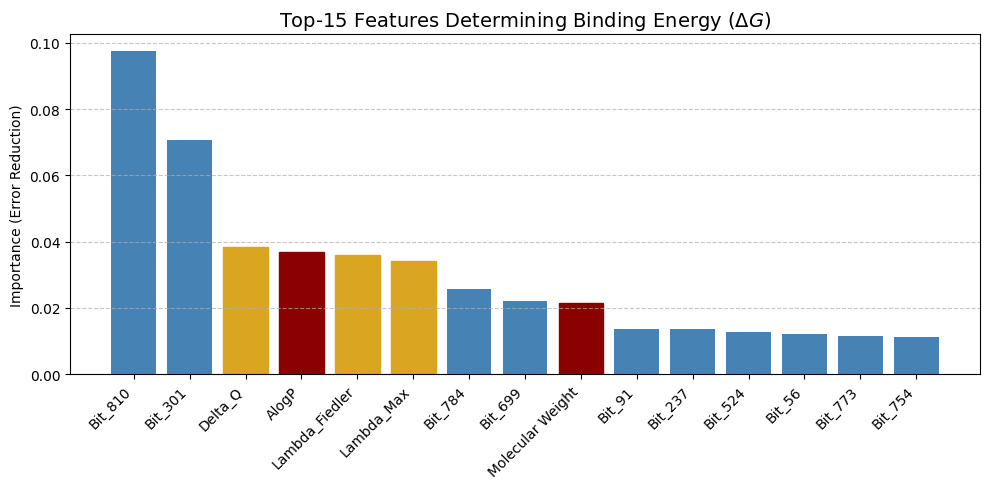

In [ ]:
DataAnalytics.plot_feature_importance(rf_model, runner_rf.feature_names)
# DataAnalytics.plot_shap_analysis(rf_model, df_clean[['Molecular Weight', 'AlogP', 'Delta_Q', 'Lambda_Max', 'Lambda_Fiedler']].values, runner_rf.feature_names)

# **Experiment 2. CatBoost**

Assembling the physicochemical feature tensor...
Final hyperspace dimensionality (X): (6290, 1029)
Training estimator: CatBoostRegressor...

 EXPERIMENTAL DETECTOR REPORT
 R^2  (Explained Variance) : 0.690
 MSE  (Error Dispersion)   : 0.435
 RMSE (Absolute Error)     : 0.660 pKi
 MAE  (Mean Deviation)     : 0.474 pKi



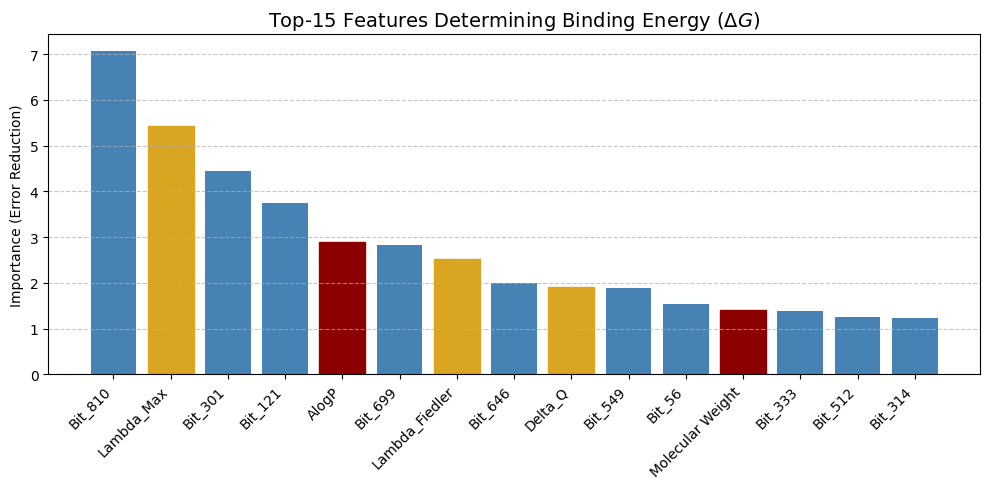

Calculating SHAP values (analyzing physical contributions)...


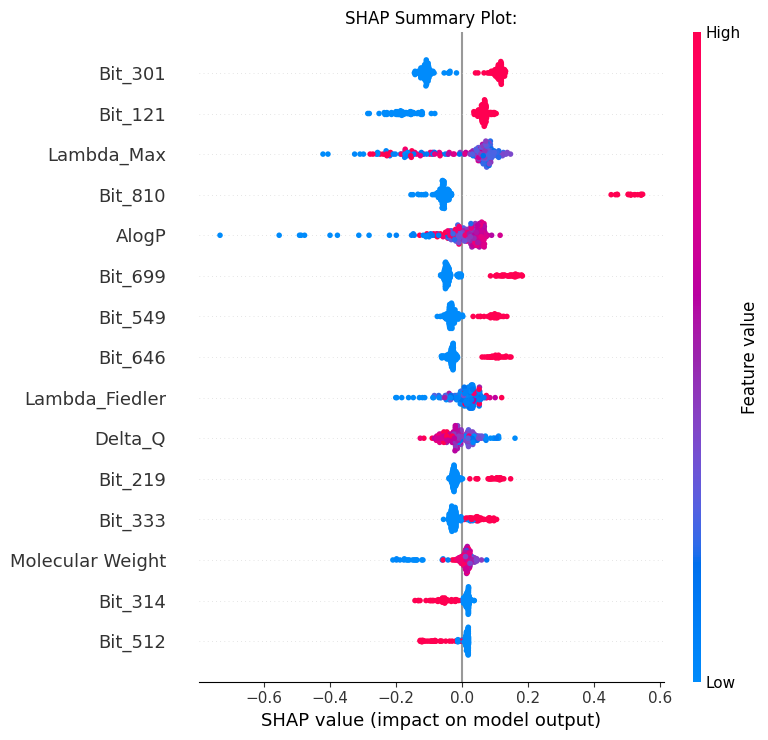

In [ ]:
settings = ExperimentSettings(USE_MORGAN=True, USE_MACRO=True, USE_2D_PHYSICS=True, USE_3D_PHYSICS=False)
cat_model = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, verbose=0, random_seed=42)
runner_cat = ExperimentRunner(model=cat_model, settings=settings)
runner_cat.run(df_clean, verbose=False, plot=False)

In [ ]:
for k, v in runner_cat.get_metrics().items():
  print(f"{k}:\t{v}")

R2:	0.690110538259645
MSE:	0.4354066866187722
RMSE:	0.6598535342170808
MAE:	0.4739017646693827


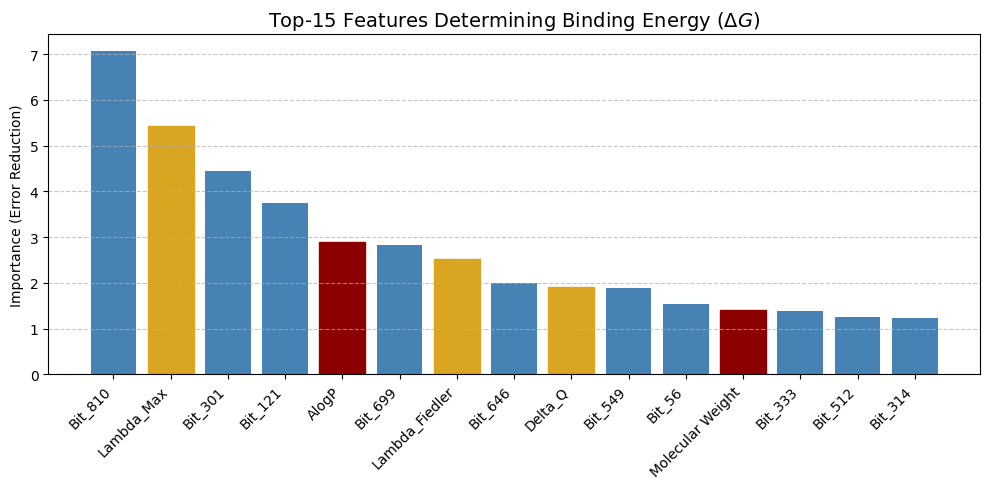

In [ ]:
DataAnalytics.plot_feature_importance(cat_model, runner_cat.feature_names)
# DataAnalytics.plot_shap_analysis(cat_model, df_clean[['Molecular Weight', 'AlogP', 'Delta_Q', 'Lambda_Max', 'Lambda_Fiedler']].values, runner_cat.feature_names)

# **Experiment 3. LGBM**

In [ ]:
settings = ExperimentSettings(USE_MORGAN=True, USE_MACRO=True, USE_2D_PHYSICS=True, USE_3D_PHYSICS=False)
lgbm_model = LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=8, random_state=42, n_jobs=-1)
runner_lgbm = ExperimentRunner(model=lgbm_model, settings=settings)
runner_lgbm.run(df_clean, verbose=False, plot=False)

Assembling the physicochemical feature tensor...
Final hyperspace dimensionality (X): (6290, 1029)
Training estimator: LGBMRegressor...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.047986 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3137
[LightGBM] [Info] Number of data points in the train set: 5032, number of used features: 936
[LightGBM] [Info] Start training from score 7.457627
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
for k, v in runner_lgbm.get_metrics().items():
  print(f"{k}:\t{v}")

R2:	0.7130008851012215
MSE:	0.4032448634387507
RMSE:	0.6350156403103396
MAE:	0.4430441724392869


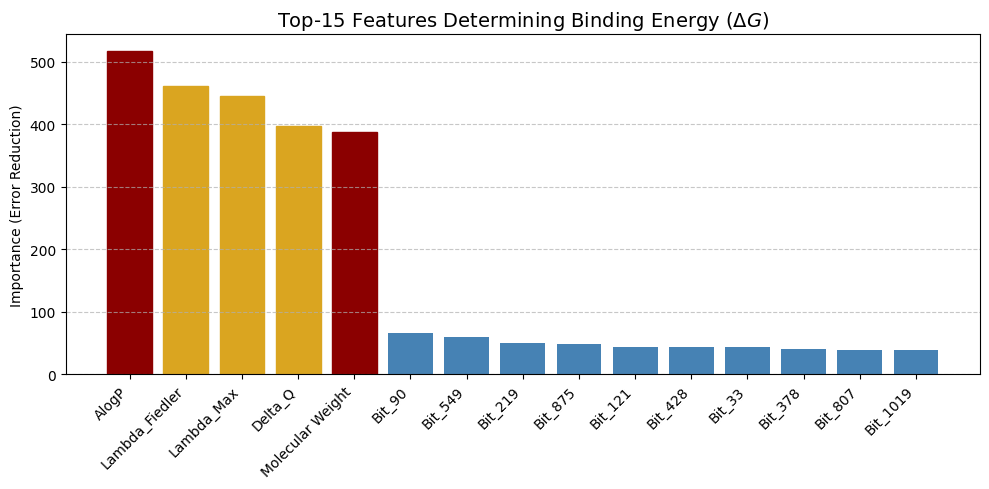

In [ ]:
DataAnalytics.plot_feature_importance(lgbm_model, runner_lgbm.feature_names)
# DataAnalytics.plot_shap_analysis(lgbm_model, df_clean[['Molecular Weight', 'AlogP', 'Delta_Q', 'Lambda_Max', 'Lambda_Fiedler']].values, runner_lgbm.feature_names)